<a href="https://colab.research.google.com/github/stephenebert/Springboard/blob/main/Mini_Project_Building_a_Flask_Application_for_a_Machine_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyngrok
!pip install flask

In [3]:
import getpass
from pyngrok import ngrok, conf

print("Enter your authtoken, which can be copied from https://dashboard.ngrok.com/auth")
conf.get_default().auth_token = getpass.getpass()

Enter your authtoken, which can be copied from https://dashboard.ngrok.com/auth
··········


In [7]:
%%bash
pip install flask pyngrok matplotlib

cat << 'EOF' > app.py
from flask import Flask, request, render_template
import matplotlib.pyplot as plt
import io, base64

app = Flask(__name__)

def generate_bar_chart(categories, values):
    plt.figure(figsize=(8, 4))
    plt.bar(categories, values)
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    plt.close()
    buf.seek(0)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

@app.route('/', methods=['GET', 'POST'])
def index():
    chart_url = None
    if request.method == 'POST':
        cats = [c.strip() for c in request.form['categories'].split(',')]
        vals = [float(v) for v in request.form['values'].split(',')]
        chart_url = generate_bar_chart(cats, vals)
    return render_template('index.html', chart_url=chart_url)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
EOF


In [9]:
!nohup python app.py &>/dev/null &

In [10]:
from pyngrok import ngrok, conf
import getpass

url = ngrok.connect(5000)
print(" * public URL: ", url)

 * public URL:  NgrokTunnel: "https://e8bc-35-227-188-224.ngrok-free.app" -> "http://localhost:5000"


**1. Write a function called generate_bar_chart that takes a list of category names and respective values and generates a bar chart using plt.bar. In the function, return your barplot as a UTF-8 encoded string. It may be useful to create a BytesIO object using io.BytesIO to store the barplot and then base64.b64encode to create the encoding.**

In [11]:
import matplotlib.pyplot as plt
import io
import base64

def generate_bar_chart(categories, values):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(categories, values)
    fig.tight_layout()

    # Save figure to a bytes buffer
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    plt.close(fig)
    buf.seek(0)

    img_bytes = buf.getvalue()
    encoded = base64.b64encode(img_bytes).decode('utf-8')
    return encoded



2. **Now, you'll be filling in the index function that serves as the landing page for our application. If you're not too familiar with how HTTP works, read this quick primer here. From the form defined in index.html, extract the input for the categories field and store it in a list. Also, extract the input for the values field and store it in a list as well.**

In [12]:
from flask import Flask, request, render_template

app = Flask(__name__)

@app.route('/', methods=['GET', 'POST'])
def index():
    chart_url = None
    if request.method == 'POST':
        # Split the comma-separated categories into a list of strings
        categories = [c.strip() for c in request.form['categories'].split(',')]
        # Split the comma-separated values into floats
        values     = [float(v)  for v in request.form['values'].split(',')]

        chart_url = generate_bar_chart(categories, values)

    # Render the template, passing in chart_url
    return render_template('index.html', chart_url=chart_url)


3. **Pass the two lists from the previous step to your function generate_bar_chart.**

In [13]:
from flask import Flask, request, render_template

app = Flask(__name__)

@app.route('/', methods=['GET', 'POST'])
def index():
    chart_url = None
    if request.method == 'POST':
        # Parse the comma-separated inputs
        categories = [c.strip() for c in request.form['categories'].split(',')]
        values     = [float(v)  for v in request.form['values'].split(',')]

        # Pass them into the chart function
        chart_url = generate_bar_chart(categories, values)

    return render_template('index.html', chart_url=chart_url)

4. The output of generate_bar_chart in the index function should then be passed to Flask's render_template and returned by the function.


5. Execute the cell below with your code and click on the link output by "ngrok tunnel". This is the application landing page. See if everything works.

In [18]:
!pip install flask pyngrok matplotlib

!nohup python app.py &>/dev/null &

# Open an ngrok tunnel to port 5000
from pyngrok import ngrok, conf
import getpass

public_url = ngrok.connect(5000)
print(f"* ngrok tunnel: {public_url}")


* ngrok tunnel: NgrokTunnel: "https://6e92-35-227-188-224.ngrok-free.app" -> "http://localhost:5000"


Here are the plots

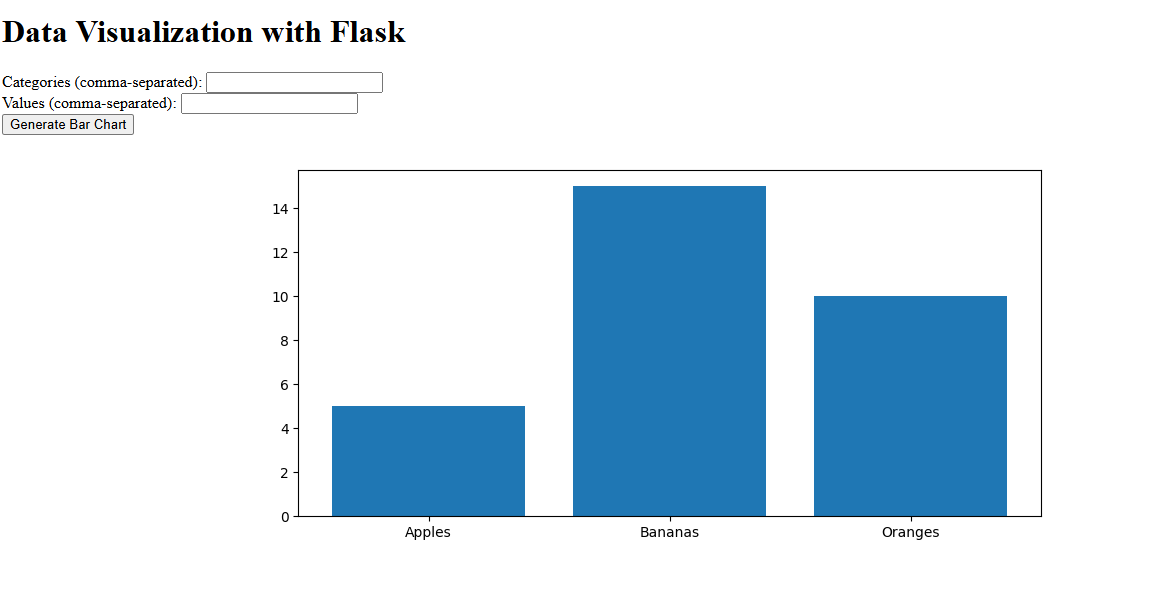

In [24]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2025-06-29 150115.png'))

6. Have fun with the application built here. See if you can extend it in some way. Make sure you understand how the python code interacts with the html template.

In the last step, we simply gave users a few more ways to personalize their chart. First, we edited our HTML template to include three new text-boxes-one for the chart title, one for the x-axis label, and one for the y-axis label so anyone could type in whatever headings made sense for their data. Then, in our Flask view, we grabbed those three new form values alongside the categories and values, cleaned them up with a quick .strip(), and passed them into our plotting helper. Inside generate_bar_chart, we added a couple of ax.set_title(), ax.set_xlabel(), and ax.set_ylabel() calls so Matplotlib would actually draw the labels on the figure. Finally, we redeployed the app behind ngrok, and now every chart generated not only shows the bars but also carries the exact title and axis captions of the user's choice.

In [19]:
%%bash
# Kill any old Flask on 5000
lsof -t -i:5000 | xargs -r kill -9

pip install flask pyngrok matplotlib

cat << 'EOF' > app.py
from flask import Flask, request, render_template
import matplotlib.pyplot as plt
import io, base64

app = Flask(__name__)

def generate_bar_chart(categories, values, title='', xlabel='', ylabel=''):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(categories, values)
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

@app.route('/', methods=['GET', 'POST'])
def index():
    chart_url = None
    if request.method == 'POST':
        cats   = [c.strip() for c in request.form['categories'].split(',')]
        vals   = [float(v)   for v in request.form['values'].split(',')]
        title  = request.form.get('title','').strip()
        xlabel = request.form.get('xlabel','').strip()
        ylabel = request.form.get('ylabel','').strip()
        chart_url = generate_bar_chart(cats, vals, title, xlabel, ylabel)
    return render_template('index.html', chart_url=chart_url)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001)
EOF

# Start Flask on port 5001 in the background
nohup python app.py &>/dev/null &


In [20]:
from pyngrok import ngrok, conf
import getpass

url = ngrok.connect(5001)
print(f"* ngrok tunnel: {url}")

* ngrok tunnel: NgrokTunnel: "https://1952-35-227-188-224.ngrok-free.app" -> "http://localhost:5001"


Here are the plots

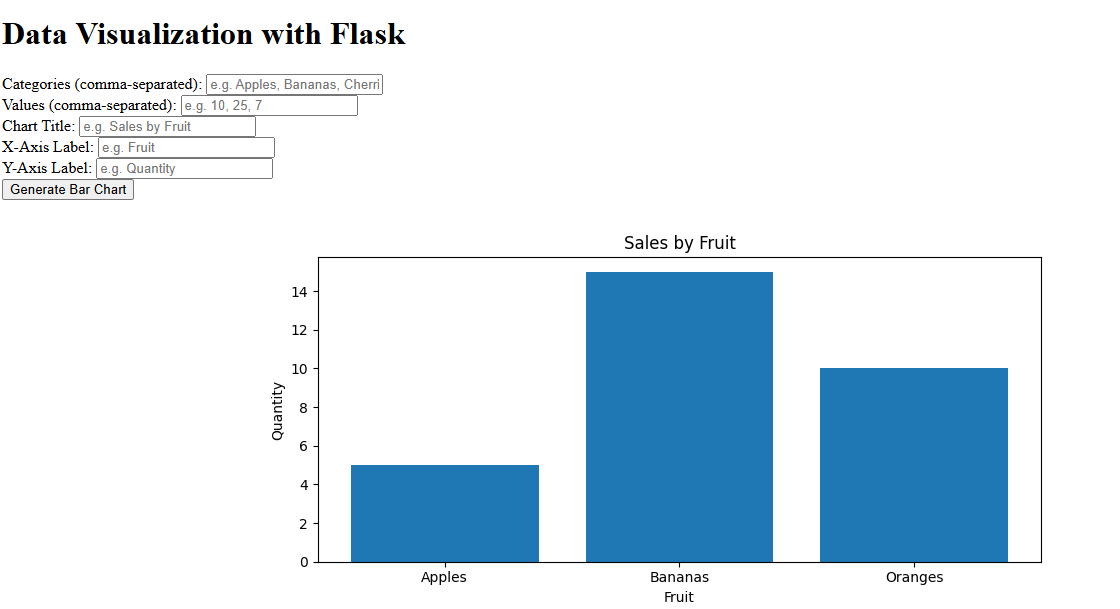

In [22]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2025-06-29 154149.png'))

and here is the modified html code

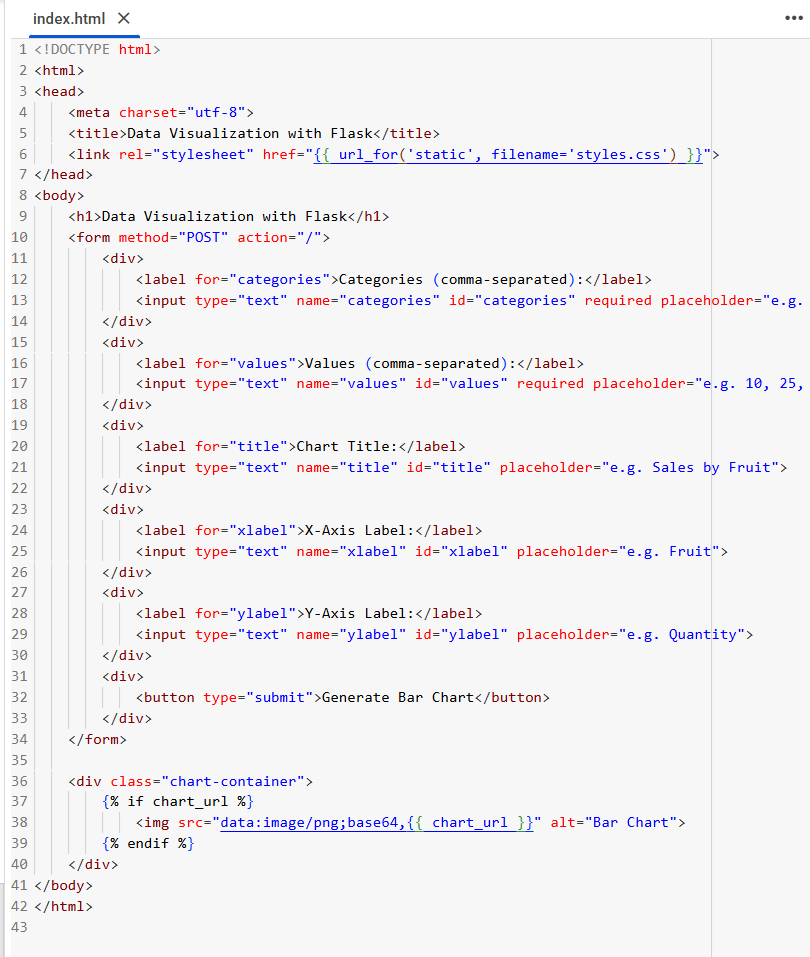

In [23]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2025-06-29 154912.png'))